# 淘宝用户行为分析：质量门槛、人数变化与加购路径

基于公开淘宝行为日志的个人分析项目。下面保留可检查的独立核心查询，并与终端脚本共用扩展 SQL。

## 核心发现

12 月 1 日 → 2 日购买用户由 1,407 增至 1,747，对称分解为 +416.75 −76.75，互斥用户分组为 +388 −9 −39。购买记录净增 509，前十品类贡献正向增量的 9.36%。

新增同星期参照仍呈现购买人数上升、购买率下降。after_only 的 2,411 人全部在 11 月 25—30 日出现；其严格 24h 加购商品对后续购买率为 77/1,485=5.19%，both_days 为 188/5,953=3.16%。12 月 2／3 日约 98% 的窗口样本用户活跃，需核查来源入选与采集范围。

[案例说明](README.md) · [业务备忘录](reports/business_memo.md) · [实验设计：尚未实施](reports/experiment_design.md) · [数据来源](data/README.md)

## 方法与运行

固定 DuckDB 1.5.5，五字段按 VARCHAR 读取，按 `hash(user_id) % 100 = 0` 选择用户。北京时间窗口为 `[2017-11-25 00:00, 2017-12-04 00:00)`。完全相同行按五个原始字段识别，保留并披露。

保留原行为字段，`behavior_type_clean = TRIM(behavior_type)` 统一用于校验和下游计算，不转换大小写。全样本任何非法／缺失行为、缺失关键 ID 或不可解析时间戳都使正式分析停止。旧成功 CSV／PNG 不会被质量失败覆盖；运行失败时这些旧文件不代表一次新的成功结果。本次规范化记录和质量问题均为 0。

从本案例目录启动 Jupyter。优先使用 `data/UserBehavior.csv` 与同目录数据库；若 CSV 位于仓库根目录则自动复用原文件。可用 `TAOBAO_CSV`、`TAOBAO_DB`、`TAOBAO_OUTPUT` 指定本地位置。已有数据库只读打开；不存在时先建立新样本。开头字段预览仍需 CSV；只有下游脚本不需要原 CSV。

请从头顺序运行；质量检查抛错后不要跳过失败单元继续执行旧变量。最后一个代码单元关闭数据库连接；中断运行时执行 `con.close()`。

### 1. 环境与相对路径

In [1]:
from pathlib import Path
import os
import pandas as pd
from prepare_data import check_version, prepare_sample, SCHEMA
from run_analysis import (
    enforce_quality, extended_tables, export_tables, buyer_decomposition,
    EXTENSION_MARKER,
)

# Start Jupyter from projects/taobao-user-behavior (see README.md).
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "run_analysis.py").is_file():
    raise RuntimeError("Start this Notebook from projects/taobao-user-behavior.")
# Prefer this case's data directory; otherwise reuse the original repository-root CSV.
default_data_dir = Path("data")
if not (default_data_dir / "UserBehavior.csv").is_file() and Path("../../UserBehavior.csv").is_file():
    default_data_dir = Path("../..")
csv_path = Path(os.environ.get("TAOBAO_CSV", str(default_data_dir / "UserBehavior.csv")))
db_path = Path(os.environ.get("TAOBAO_DB", str(default_data_dir / "taobao.duckdb")))
output_dir = Path(os.environ.get("TAOBAO_OUTPUT", "outputs"))
check_version()
print("CSV available:", csv_path.is_file())
print("DuckDB version checked: 1.5.5")

CSV available: True
DuckDB version checked: 1.5.5


### 2. 读取少量记录，检查五字段结构

In [2]:
columns = [
    "user_id",
    "item_id",
    "category_id",
    "behavior_type",
    "timestamp"
]

preview = pd.read_csv(
    csv_path,
    header=None,
    names=columns,
    nrows=10,
    dtype="string"
)

print("Preview shape (raw rows kept local):", preview.shape)

Preview shape (raw rows kept local): (10, 5)


### 3. 字段类型

In [3]:
print("Table shape:", preview.shape)
print("Column names:", preview.columns.tolist())

preview.dtypes


Table shape: (10, 5)
Column names: ['user_id', 'item_id', 'category_id', 'behavior_type', 'timestamp']


user_id          string
item_id          string
category_id      string
behavior_type    string
timestamp        string
dtype: object

### 4. 将 Unix 秒转换为北京时间

In [4]:
timestamp_seconds = pd.to_numeric(
    preview["timestamp"],
    errors="coerce"
)

preview["event_time"] = pd.to_datetime(
    timestamp_seconds,
    unit="s",
    utc=True,
    errors="coerce"
).dt.tz_convert("Asia/Shanghai")

preview["event_date"] = preview["event_time"].dt.date
preview["event_hour"] = preview["event_time"].dt.hour

print("Missing or invalid times:", preview["event_time"].isna().sum())

print("Preview date range:", preview["event_date"].min(), "to", preview["event_date"].max())

Missing or invalid times: 0
Preview date range: 2017-11-25 to 2017-11-27


### 5. 准备样本并只读连接数据库

In [5]:
import duckdb

# Create a sample only in a new database; existing databases stay read-only.
if not db_path.exists():
    print(prepare_sample(csv_path, db_path).to_string(index=False))
con = duckdb.connect(str(db_path), read_only=True)
con.execute("SET memory_limit = '1GB'")
actual_schema = {row[0]: row[1] for row in con.execute("DESCRIBE sample_events").fetchall()}
if actual_schema != SCHEMA:
    con.close()
    raise ValueError("sample_events must contain the five original VARCHAR columns.")
print("DuckDB version:", duckdb.__version__)
print("Existing sample opened read-only")

DuckDB version: 1.5.5
Existing sample opened read-only


### 6. 保留原始行为字段，派生规范化字段

In [6]:
con.execute("""
    CREATE OR REPLACE TEMP VIEW normalized_sample_events AS
    SELECT *, TRIM(behavior_type) AS behavior_type_clean FROM sample_events
""")
print("Raw behavior_type preserved; behavior_type_clean applies TRIM only")

Raw behavior_type preserved; behavior_type_clean applies TRIM only


### 7. 原样本规模

In [7]:
sample_info = con.execute("""
    SELECT
        COUNT(*) AS event_records,
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT item_id) AS items
    FROM sample_events
""").df()

sample_info

,event_records,users,items
0,994112,9915,400718


### 8. 行为类型分布

In [8]:
behavior_counts = con.execute("""
    SELECT
        behavior_type_clean,
        COUNT(*) AS event_records
    FROM normalized_sample_events
    GROUP BY behavior_type_clean
    ORDER BY event_records DESC
""").df()

behavior_counts

,behavior_type_clean,event_records
0,pv,890632
1,cart,54226
2,fav,29225
3,buy,20029


### 9. 质量检查决定正式分析能否继续

In [9]:
quality_check = con.execute("""
    SELECT
        COUNT(*) AS total_records,
    COUNT(*) FILTER (WHERE behavior_type <> behavior_type_clean)
        AS normalized_behavior_records,

        COUNT(*) FILTER (
            WHERE user_id IS NULL OR TRIM(user_id) = ''
        ) AS missing_user_id,

        COUNT(*) FILTER (
            WHERE item_id IS NULL OR TRIM(item_id) = ''
        ) AS missing_item_id,

        COUNT(*) FILTER (
            WHERE category_id IS NULL OR TRIM(category_id) = ''
        ) AS missing_category_id,

        COUNT(*) FILTER (
            WHERE behavior_type_clean IS NULL
               OR behavior_type_clean NOT IN ('pv', 'fav', 'cart', 'buy')
        ) AS invalid_behavior,

        COUNT(*) FILTER (
            WHERE TRY(to_timestamp(TRY_CAST(timestamp AS BIGINT))
                  AT TIME ZONE 'Asia/Shanghai') IS NULL
        ) AS invalid_timestamp

    FROM normalized_sample_events
""").df()

print(quality_check.to_string(index=False))
try:
    enforce_quality(quality_check)
except ValueError:
    con.close()
    raise
quality_check

 total_records  normalized_behavior_records  missing_user_id  missing_item_id  missing_category_id  invalid_behavior  invalid_timestamp
        994112                            0                0                0                    0                 0                  0


,total_records,normalized_behavior_records,missing_user_id,missing_item_id,missing_category_id,invalid_behavior,invalid_timestamp
0,994112,0,0,0,0,0,0


### 10. 原样本时间范围

In [10]:
time_check = con.execute("""
    SELECT
        MIN(TRY_CAST(timestamp AS BIGINT)) AS min_timestamp,
        MAX(TRY_CAST(timestamp AS BIGINT)) AS max_timestamp
    FROM sample_events
""").df()

time_check["earliest_time"] = pd.to_datetime(
    time_check["min_timestamp"],
    unit="s",
    utc=True,
    errors="coerce"
).dt.tz_convert("Asia/Shanghai")

time_check["latest_time"] = pd.to_datetime(
    time_check["max_timestamp"],
    unit="s",
    utc=True,
    errors="coerce"
).dt.tz_convert("Asia/Shanghai")

time_check

,min_timestamp,max_timestamp,earliest_time,latest_time
0,1504009322,1519555216,2017-08-29 20:22:02+08:00,2018-02-25 18:40:16+08:00


### 11. 完全相同行检查：保留并披露

In [11]:
duplicate_check = con.execute("""
    SELECT
        COUNT(*) AS total_records,

        COUNT(DISTINCT (
            user_id,
            item_id,
            category_id,
            behavior_type,
            timestamp
        )) AS distinct_combinations

    FROM sample_events
""").df()

duplicate_check["extra_identical_records"] = (
    duplicate_check["total_records"]
    - duplicate_check["distinct_combinations"]
)

duplicate_check

,total_records,distinct_combinations,extra_identical_records
0,994112,994111,1


### 12. 左闭右开时间窗检查

In [12]:
start_ts = int(
    pd.Timestamp("2017-11-25", tz="Asia/Shanghai").timestamp()
)
end_ts = int(
    pd.Timestamp("2017-12-04", tz="Asia/Shanghai").timestamp()
)

params = {
    "start_ts": start_ts,
    "end_ts": end_ts
}

range_check = con.execute("""
    WITH parsed AS (
        SELECT
            TRY_CAST(timestamp AS BIGINT) AS epoch_seconds
        FROM sample_events
    )
    SELECT
        COUNT(*) AS total_records,

        COUNT(*) FILTER (
            WHERE epoch_seconds IS NULL
        ) AS invalid_timestamp,

        COUNT(*) FILTER (
            WHERE epoch_seconds < $start_ts
        ) AS before_window,

        COUNT(*) FILTER (
            WHERE epoch_seconds >= $start_ts
              AND epoch_seconds < $end_ts
        ) AS in_window,

        COUNT(*) FILTER (
            WHERE epoch_seconds >= $end_ts
        ) AS after_window

    FROM parsed
""", params).df()

range_check

,total_records,invalid_timestamp,before_window,in_window,after_window
0,994112,0,526,993560,26


### 13. 建立窗口内事件表

In [13]:
con.execute("""
    CREATE OR REPLACE TEMP TABLE final_events AS

    WITH parsed AS (
        SELECT
            *,
            TRY_CAST(timestamp AS BIGINT) AS epoch_seconds
        FROM normalized_sample_events
    ),

    localized AS (
        SELECT
            user_id,
            item_id,
            category_id,
            behavior_type,
            behavior_type_clean,
            timestamp,

            to_timestamp(epoch_seconds)
                AT TIME ZONE 'Asia/Shanghai' AS event_time

        FROM parsed
        WHERE epoch_seconds >= $start_ts
          AND epoch_seconds < $end_ts
    )

    SELECT
        *,
        CAST(event_time AS DATE) AS event_date,
        EXTRACT(HOUR FROM event_time) AS event_hour
    FROM localized
""", params)

analysis_summary = con.execute("""
    SELECT
        COUNT(*) AS event_records,
        COUNT(DISTINCT user_id) AS users,
        MIN(event_time) AS earliest_time,
        MAX(event_time) AS latest_time
    FROM final_events
""").df()

assert (
    int(analysis_summary["event_records"].iloc[0])
    == int(range_check["in_window"].iloc[0])
)

analysis_summary

,event_records,users,earliest_time,latest_time
0,993560,9915,2017-11-25,2017-12-03 23:59:54


### 14. 每日活跃用户、购买用户与购买记录

In [14]:
daily_metrics = con.execute("""
    WITH daily AS (
        SELECT
            event_date,

            COUNT(*) AS event_records,

            COUNT(DISTINCT event_hour) AS observed_hours,

            COUNT(DISTINCT user_id) AS active_users,

            COUNT(DISTINCT user_id) FILTER (
                WHERE behavior_type_clean = 'buy'
            ) AS buyers,

            COUNT(*) FILTER (
                WHERE behavior_type_clean = 'buy'
            ) AS buy_events

        FROM final_events
        GROUP BY event_date
    )

    SELECT
        *,
        buyers * 1.0 / NULLIF(active_users, 0) AS buyer_rate,
        (SELECT COUNT(DISTINCT user_id) FROM final_events) AS window_sample_users,
        active_users * 1.0 / NULLIF((SELECT COUNT(DISTINCT user_id) FROM final_events), 0)
            AS sample_active_share

    FROM daily
    ORDER BY event_date
""").df()

daily_metrics

,event_date,event_records,observed_hours,active_users,buyers,buy_events,buyer_rate,window_sample_users,sample_active_share
0,2017-11-25,105516,24,7132,1349,2033,0.189148,9915,0.719314
1,2017-11-26,106453,24,7201,1375,2047,0.190946,9915,0.726273
2,2017-11-27,98878,24,7088,1475,2243,0.208098,9915,0.714876
3,2017-11-28,98279,24,7106,1388,2064,0.195328,9915,0.716692
4,2017-11-29,101915,24,7162,1472,2297,0.205529,9915,0.722340
5,2017-11-30,103188,24,7256,1439,2110,0.198319,9915,0.731820
6,2017-12-01,107285,24,7456,1407,2096,0.188707,9915,0.751992
7,2017-12-02,136153,24,9718,1747,2605,0.179769,9915,0.980131
8,2017-12-03,135893,24,9702,1725,2534,0.177798,9915,0.978517


### 15. 每日汇总与总量核对

In [15]:
print("Days covered:", len(daily_metrics))

print(
    "Total daily records:",
    int(daily_metrics["event_records"].sum())
)

print(
    "Record counts match:",
    int(daily_metrics["event_records"].sum())
    == int(analysis_summary["event_records"].iloc[0])
)

Days covered: 9
Total daily records: 993560
Record counts match: True


### 16. 九天趋势

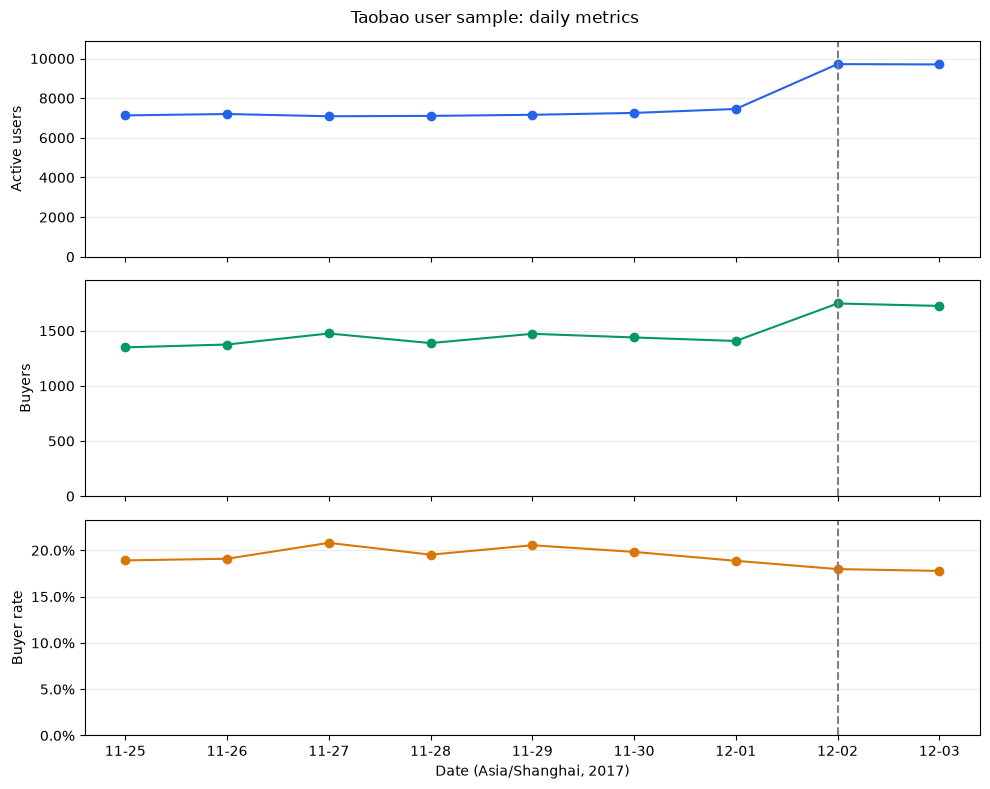

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

trend = daily_metrics.copy()
trend["event_date"] = pd.to_datetime(trend["event_date"])
trend = trend.sort_values("event_date")

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 8),
    sharex=True
)

metrics = [
    ("active_users", "Active users", "#2563EB"),
    ("buyers", "Buyers", "#059669"),
    ("buyer_rate", "Buyer rate", "#D97706")
]

for ax, (column, label, color) in zip(axes, metrics):
    ax.plot(
        trend["event_date"],
        trend[column],
        marker="o",
        color=color
    )
    ax.set_ylabel(label)
    ax.set_ylim(0, float(trend[column].max()) * 1.12)
    ax.axvline(
        pd.Timestamp("2017-12-02"),
        color="gray",
        linestyle="--"
    )
    ax.grid(axis="y", alpha=0.25)

axes[2].yaxis.set_major_formatter(PercentFormatter(xmax=1))
axes[2].xaxis.set_major_locator(mdates.DayLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axes[2].set_xlabel("Date (Asia/Shanghai, 2017)")

fig.suptitle("Taobao user sample: daily metrics")
fig.tight_layout()


plt.show()

12 月 2 日活跃人数与购买人数上升，购买率下降。下文分别通过规模／购买率和互斥用户组核对这一变化。竖线标出比较日，不代表已知业务干预。

### 17. 购买人数的对称分解

In [17]:
indexed = trend.set_index("event_date")

baseline = indexed.loc[pd.Timestamp("2017-12-01")]
comparison = indexed.loc[pd.Timestamp("2017-12-02")]

A0 = baseline["active_users"]
A1 = comparison["active_users"]

B0 = baseline["buyers"]
B1 = comparison["buyers"]

r0 = B0 / A0
r1 = B1 / A1

scale_effect = (A1 - A0) * (r0 + r1) / 2
rate_effect = (r1 - r0) * (A0 + A1) / 2

print(f"Active-user component: {scale_effect:+.2f}")
print(f"Buyer-rate component: {rate_effect:+.2f}")
print(f"Sum of components: {scale_effect + rate_effect:+.2f}")
print(f"Actual buyer change: {B1 - B0:+.0f}")
print(f"Residual: {(B1 - B0) - (scale_effect + rate_effect):.8f}")

Active-user component: +416.75
Buyer-rate component: -76.75
Sum of components: +340.00
Actual buyer change: +340
Residual: 0.00000000


### 18. 两天用户状态聚合（仅公开人数）

In [18]:
con.execute("""
    CREATE OR REPLACE TEMP TABLE final_user_two_day AS

    SELECT
        user_id,

        MAX(CASE
            WHEN event_date = DATE '2017-12-01'
            THEN 1 ELSE 0
        END) AS active_before,

        MAX(CASE
            WHEN event_date = DATE '2017-12-02'
            THEN 1 ELSE 0
        END) AS active_after,

        MAX(CASE
            WHEN event_date = DATE '2017-12-01'
             AND behavior_type_clean = 'buy'
            THEN 1 ELSE 0
        END) AS buyer_before,

        MAX(CASE
            WHEN event_date = DATE '2017-12-02'
             AND behavior_type_clean = 'buy'
            THEN 1 ELSE 0
        END) AS buyer_after

    FROM final_events

    WHERE event_date IN (
        DATE '2017-12-01',
        DATE '2017-12-02'
    )

    GROUP BY user_id
""")

con.execute("""
    SELECT COUNT(*) AS users_in_two_day_union
    FROM final_user_two_day
""").df()

,users_in_two_day_union
0,9867


### 19. 互斥活跃人群分组

In [19]:
cohort_summary = con.execute("""
    WITH labeled AS (
        SELECT
            *,
            CASE
                WHEN active_before = 1 AND active_after = 1
                    THEN 'both_days'
                WHEN active_before = 1
                    THEN 'before_only'
                ELSE 'after_only'
            END AS cohort
        FROM final_user_two_day
    ),

    summary AS (
        SELECT
            cohort,
            COUNT(*) AS users,

            SUM(active_before) AS active_before,
            SUM(active_after) AS active_after,

            SUM(buyer_before) AS buyers_before,
            SUM(buyer_after) AS buyers_after

        FROM labeled
        GROUP BY cohort
    )

    SELECT
        *,

        buyers_before * 1.0
            / NULLIF(active_before, 0) AS rate_before,

        buyers_after * 1.0
            / NULLIF(active_after, 0) AS rate_after,

        buyers_after - buyers_before AS buyer_change

    FROM summary
    ORDER BY buyer_change DESC, cohort
""").df()

cohort_summary

,cohort,users,active_before,active_after,buyers_before,buyers_after,rate_before,rate_after,buyer_change
0,after_only,2411,0.0,2411.0,0.0,388.0,NaN,0.160929,388.0
1,both_days,7307,7307.0,7307.0,1368.0,1359.0,0.187218,0.185986,-9.0
2,before_only,149,149.0,0.0,39.0,0.0,0.261745,NaN,-39.0


`after_only` 仅指两天中只在后一天活跃，不能解释为新注册。三组分别为 +388、−9、−39 位购买用户，合计 +340。

### 20. 用户组与整体购买人数核对

In [20]:
cohort_summary[
    [
        "active_before",
        "active_after",
        "buyers_before",
        "buyers_after",
        "buyer_change"
    ]
].sum()

active_before    7456.0
active_after     9718.0
buyers_before    1407.0
buyers_after     1747.0
buyer_change      340.0
dtype: float64

### 21. 按品类统计购买记录变化

In [21]:
category_change = con.execute("""
    WITH category_counts AS (
        SELECT
            category_id,

            COUNT(*) FILTER (
                WHERE event_date = DATE '2017-12-01'
            ) AS buy_events_before,

            COUNT(*) FILTER (
                WHERE event_date = DATE '2017-12-02'
            ) AS buy_events_after

        FROM final_events

        WHERE behavior_type_clean = 'buy'
          AND event_date IN (
              DATE '2017-12-01',
              DATE '2017-12-02'
          )

        GROUP BY category_id
    )

    SELECT
        *,
        buy_events_after - buy_events_before AS buy_event_change

    FROM category_counts
    ORDER BY buy_event_change DESC, category_id
""").df()

category_change.head(10)

,category_id,buy_events_before,buy_events_after,buy_event_change
0,2735466,34,49,15
1,570735,15,30,15
2,2885642,35,49,14
3,3158249,5,16,11
4,3776866,2,13,11
5,4801426,27,38,11
6,1879194,13,23,10
7,2297500,2,12,10
8,3738615,6,16,10
9,4357323,11,21,10


### 22. 品类与整体购买记录核对

In [22]:
category_change[
    [
        "buy_events_before",
        "buy_events_after",
        "buy_event_change"
    ]
].sum()

buy_events_before    2096
buy_events_after     2605
buy_event_change      509
dtype: int64

### 23. 正向增量、负向变化与前十占比

In [23]:
changes = category_change["buy_event_change"]

positive_total = int(changes[changes > 0].sum())
negative_total = int(changes[changes < 0].sum())
net_total = int(changes.sum())

top10_positive = int(
    changes[changes > 0].nlargest(10).sum()
)

category_summary = pd.DataFrame.from_dict(
    {
        "categories_with_purchases": len(changes),
        "growing_categories": int((changes > 0).sum()),
        "declining_categories": int((changes < 0).sum()),
        "unchanged_categories": int((changes == 0).sum()),
        "positive_change_total": positive_total,
        "negative_change_total": negative_total,
        "net_change": net_total,
        "top10_positive_change": top10_positive,
        "top10_share_of_positive_change":
            top10_positive / positive_total
    },
    orient="index",
    columns=["value"]
)

print(
    f"Reconciliation: "
    f"{positive_total} + ({negative_total}) = {net_total}"
)

category_summary

Reconciliation: 1250 + (-741) = 509


,value
categories_with_purchases,1345.0000
growing_categories,709.0000
declining_categories,491.0000
unchanged_categories,145.0000
positive_change_total,1250.0000
negative_change_total,-741.0000
net_change,509.0000
top10_positive_change,117.0000
top10_share_of_positive_change,0.0936


正向变化 1,250 与负向变化 −741 相抵，净增 509 条购买行为记录。前十贡献 117 / 1,250 = 9.36%，分母是正向增量。

## 同星期参照与 after_only 深入分析

以下三张表复用 `analysis.sql` 的扩展查询，输入为上面独立查询产生的规范化事件、用户状态和每日指标。数值均由当前数据库计算。

In [24]:
con.register("notebook_daily", daily_metrics)
con.execute("CREATE OR REPLACE TEMP TABLE final_daily_metrics AS SELECT * FROM notebook_daily")
sql = (PROJECT_DIR / "analysis.sql").read_text(encoding="utf-8")
con.execute(sql.split(EXTENSION_MARKER, 1)[1].split("\n", 1)[1])
extra_tables = extended_tables(con)

### 同星期比较与样本活跃占比

相对变化列使用比例（展示时乘 100 为百分比）；`buyer_rate_change_pp` 已是百分点。`sample_active_share` 的分母是窗口内全部样本用户，不能解释为平台渗透率。

In [25]:
weekday_comparison = extra_tables["weekday_comparison"]
weekday_comparison

,comparison,before_date,after_date,active_users_before,active_users_after,active_users_change,active_users_relative_change,buyers_before,buyers_after,buyers_change,buyers_relative_change,buyer_rate_before,buyer_rate_after,buyer_rate_change_pp,buy_events_before,buy_events_after,buy_events_change
0,saturday,2017-11-25,2017-12-02,7132,9718,2586,0.362591,1349,1747,398,0.295033,0.189148,0.179769,-0.937800,2033,2605,572
1,sunday,2017-11-26,2017-12-03,7201,9702,2501,0.347313,1375,1725,350,0.254545,0.190946,0.177798,-1.314731,2047,2534,487
2,adjacent_days,2017-12-01,2017-12-02,7456,9718,2262,0.303380,1407,1747,340,0.241649,0.188707,0.179769,-0.893758,2096,2605,509


In [26]:
daily_metrics[["event_date", "active_users", "window_sample_users", "sample_active_share"]]

,event_date,active_users,window_sample_users,sample_active_share
0,2017-11-25,7132,9915,0.719314
1,2017-11-26,7201,9915,0.726273
2,2017-11-27,7088,9915,0.714876
3,2017-11-28,7106,9915,0.716692
4,2017-11-29,7162,9915,0.722340
5,2017-11-30,7256,9915,0.731820
6,2017-12-01,7456,9915,0.751992
7,2017-12-02,9718,9915,0.980131
8,2017-12-03,9702,9915,0.978517


同周六活跃人数 +36.26%、购买人数 +29.50%，购买率 −0.94 个百分点；同周日分别为 +34.73%、+25.45%、−1.31 个百分点。每天活跃人数分母是窗口内 9,915 位样本用户，12 月 2／3 日比例为 98.01%／97.85%。九天只能提供有限参照，不能建立稳定季节性基线；接近全样本活跃需要核查用户入选和采集范围，不能称为平台渗透率。

### after_only 在更早窗口是否出现

只使用 11 月 25—30 日判断此前是否出现。两组互斥且完整，未出现不等于新注册，不能据此识别 30—60 天未购买老客。

In [27]:
after_only_history = extra_tables["after_only_history"]
after_only_history

,history_group,users,buyers,buyer_rate,event_records,pv_events,cart_events,buy_events,cart_users,events_per_user
0,not_seen_earlier_in_window,0,0.0,NaN,0.0,0.0,0.0,0.0,0,NaN
1,seen_earlier_in_window,2411,388.0,0.160929,25597.0,22773.0,1499.0,592.0,673,10.616757


两组人数与购买人数分别汇总回 after_only 的 2,411 和 388。当前全部在更早窗口出现，未出现组为零，购买率无定义，保留空值。不能把 12 月 1 日未出现等同于新用户，也不能识别长期沉默老客。

### 24小时加购商品对后续购买率

起点是 12 月 2 日每个用户—商品对的首次加购。分母为有完整 24 小时观察范围的去重对，分子为同用户、同商品在 `(首次加购, 首次加购 + 24h]` 内出现购买的对。记录窗口右端不包含，因此起点 + 24h 必须严格早于 12 月 4 日零点。

同秒购买单独披露；只有同秒购买而无严格后续购买的对不算成功。同一对既有同秒购买又有严格后续购买时，可按后者计一次成功。重复加购与购买不放大分母或分子。这里衡量日志中的后续购买关联，不表示加购导致购买。

In [28]:
cart_to_buy_24h = extra_tables["cart_to_buy_24h"]
cart_to_buy_24h

,cohort,start_pairs,excluded_incomplete_pairs,eligible_pairs,eligible_users,success_pairs,same_second_buy_pairs,same_second_only_pairs,cart_item_pair_buy_rate_24h
0,after_only,1485,0,1485,673,77,0,0,0.051852
1,all,7438,0,7438,3251,265,0,0,0.035628
2,both_days,5953,0,5953,2578,188,0,0,0.031581


after_only 为 77/1,485=5.19%，both_days 为 188/5,953=3.16%，合计 265/7,438=3.56%。本次观察不足排除与同秒购买对均为零，代码仍处理两类边界。这里以有加购的用户—商品对为分母，窗口延伸至次日，不能与日用户购买率比较高低，也不能由组间差异推断用户质量、产品故障或策略效果。

### 导出通过质量检查与汇总核对的结果

Validated aggregate tables and charts saved.


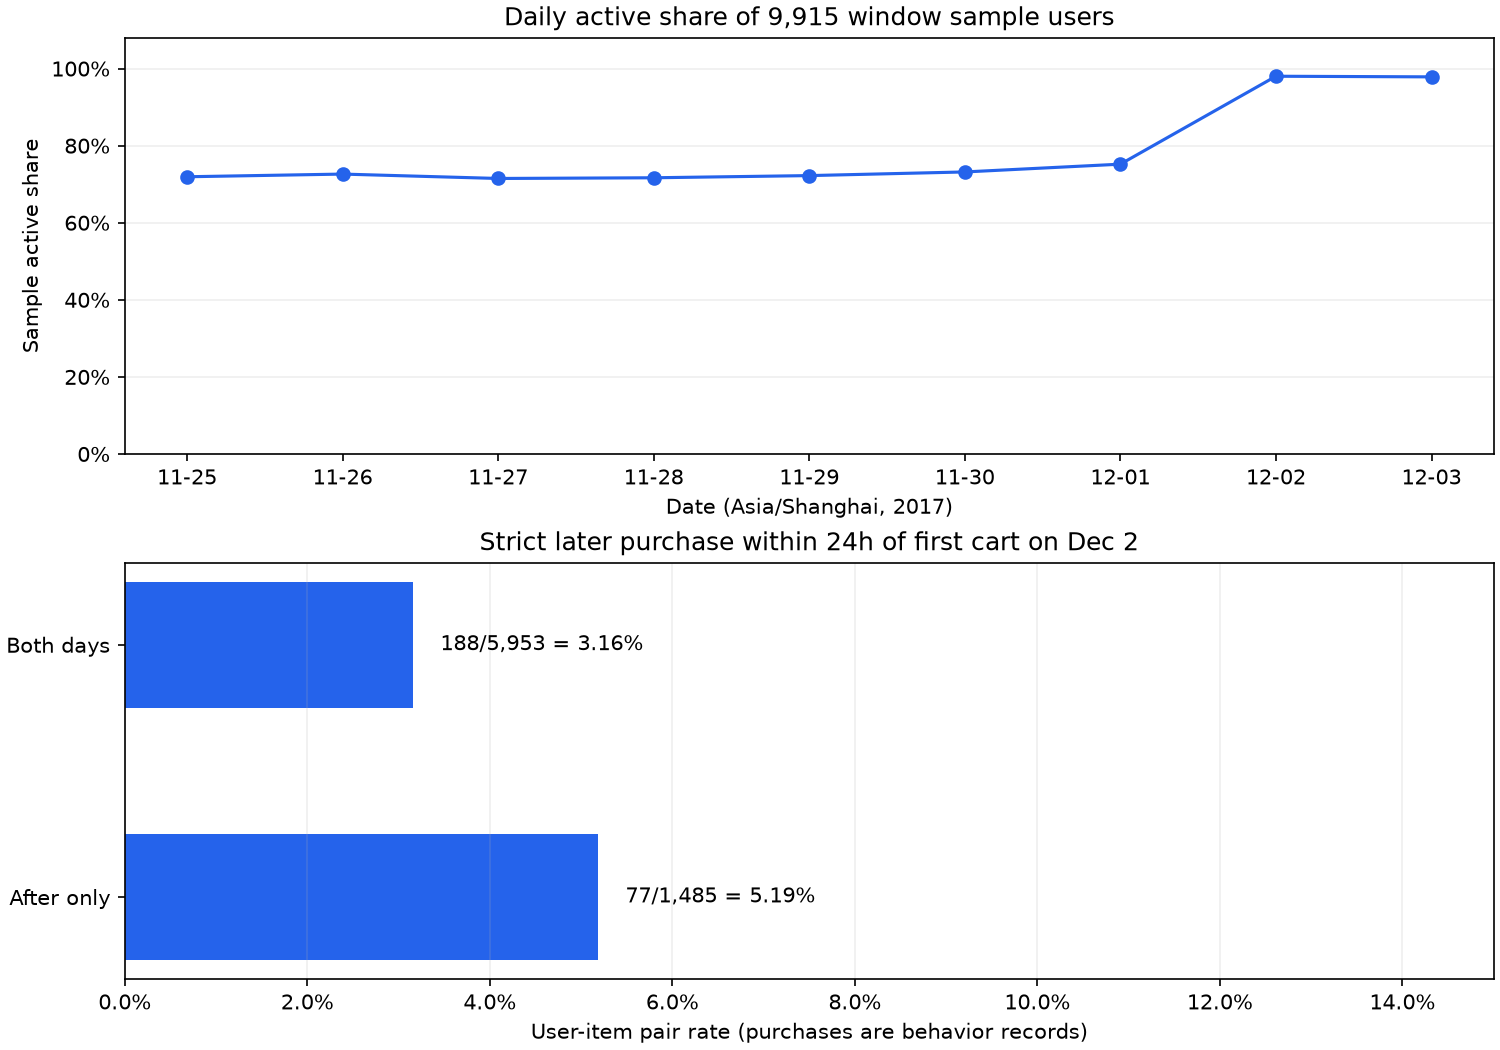

In [29]:
tables = {
    "sample_summary": sample_info,
    "quality_check": quality_check,
    "duplicate_check": duplicate_check,
    "range_check": range_check,
    "analysis_summary": analysis_summary,
    "daily_metrics": daily_metrics,
    "cohort_summary": cohort_summary,
    "category_change": category_change,
    "category_summary": category_summary,
    "buyer_decomposition": buyer_decomposition(daily_metrics),
    **extra_tables,
}
export_tables(tables, output_dir)
print("Validated aggregate tables and charts saved.")
from IPython.display import Image, display
display(Image(filename=str(output_dir / "context_diagnostics.png")))

### 关闭数据库连接

In [30]:
con.close()
print("Database connection closed.")

Database connection closed.


## 下一步：候选解释与实验设计

先核查源样本入选、采集范围与实时日志。历史差异不足以证明用户遗忘或路径故障。[实验方案](reports/experiment_design.md) 提出对近期有行为、前一天未活跃且当前加购用户提供回访入口的候选假设，定义分流前资格、用户级随机化、固定 24h 主指标及护栏。方案尚未实施，历史用户 hash 抽样和两天比较都不是 A/B 实验。

购买行为记录不是订单，缺少金额不能计算 GMV。每日覆盖 24 个小时不保证无漏报；结论限于公开样本。